In [11]:
import pandas as pd
import numpy as np

np.random.seed(100)

rows = 1000

data = {
    "Order_ID": np.arange(1, rows + 1),
    "Order_Date": pd.date_range(start="2022-01-01", periods=rows, freq="D"),
    "Region": np.random.choice(["East", "West", "North", "South"], rows),
    "Category": np.random.choice(["Technology", "Furniture", "Office Supplies"], rows),
    "Sales": np.random.randint(100, 5000, rows),
    "Quantity": np.random.randint(1, 10, rows)
}

df = pd.DataFrame(data)
df.head()

,Order_ID,Order_Date,Region,Category,Sales,Quantity
0,1,2022-01-01,East,Technology,327,8
1,2,2022-01-02,East,Furniture,3221,3
2,3,2022-01-03,South,Technology,2985,2
3,4,2022-01-04,South,Technology,4395,3
4,5,2022-01-05,South,Technology,3164,6


In [12]:
df.to_csv("sales_data.csv", index=False)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Order_ID    1000 non-null   int64         
 1   Order_Date  1000 non-null   datetime64[ns]
 2   Region      1000 non-null   object        
 3   Category    1000 non-null   object        
 4   Sales       1000 non-null   int64         
 5   Quantity    1000 non-null   int64         
dtypes: datetime64[ns](1), int64(3), object(2)
memory usage: 47.0+ KB


In [14]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])
df["Year"] = df["Order_Date"].dt.year
df["Month"] = df["Order_Date"].dt.month

df.describe()

,Order_ID,Order_Date,Sales,Quantity,Year,Month
count,1000.000000,1000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-05-15 12:00:00,2572.384000,5.066000,2022.905000,6.100000
min,1.000000,2022-01-01 00:00:00,127.000000,1.000000,2022.000000,1.000000
25%,250.750000,2022-09-07 18:00:00,1407.750000,3.000000,2022.000000,3.000000
50%,500.500000,2023-05-15 12:00:00,2615.500000,5.000000,2023.000000,6.000000
75%,750.250000,2024-01-20 06:00:00,3739.500000,7.000000,2024.000000,9.000000
max,1000.000000,2024-09-26 00:00:00,4991.000000,9.000000,2024.000000,12.000000
std,288.819436,NaN,1379.511136,2.562462,0.791582,3.307407


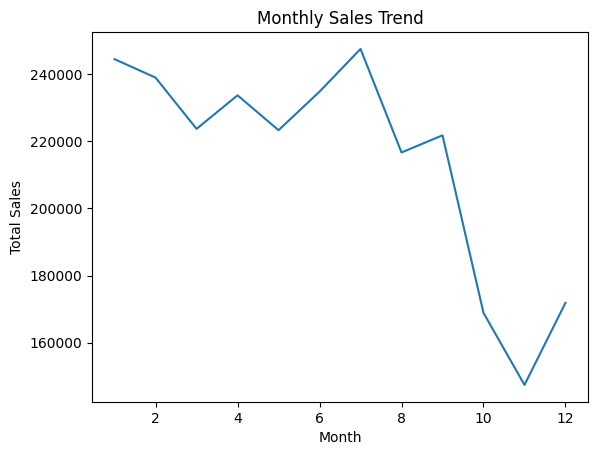

In [15]:
import matplotlib.pyplot as plt

sales_by_month = df.groupby("Month")["Sales"].sum()

plt.figure()
sales_by_month.plot(kind="line")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

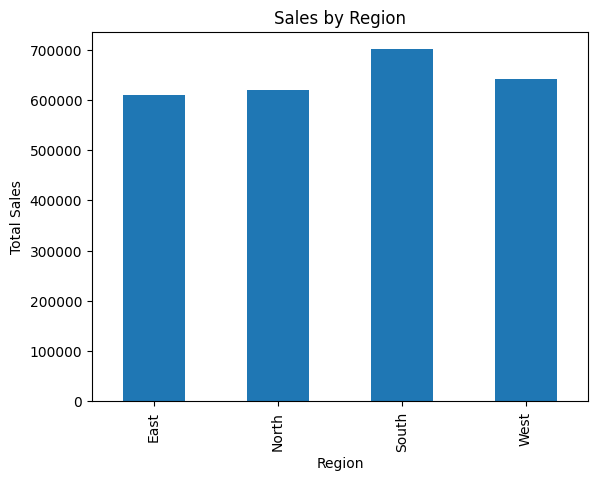

In [16]:
sales_by_region = df.groupby("Region")["Sales"].sum()

plt.figure()
sales_by_region.plot(kind="bar")
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()

In [17]:
from sklearn.linear_model import LinearRegression

df_ml = df.groupby("Order_Date")["Sales"].sum().reset_index()
df_ml["Day"] = np.arange(len(df_ml))

X = df_ml[["Day"]]
y = df_ml["Sales"]

model = LinearRegression()
model.fit(X, y)

df_ml["Predicted_Sales"] = model.predict(X)

df_ml.head()

,Order_Date,Sales,Day,Predicted_Sales
0,2022-01-01,327,0,2512.096240
1,2022-01-02,3221,1,2512.216936
2,2022-01-03,2985,2,2512.337632
3,2022-01-04,4395,3,2512.458328
4,2022-01-05,3164,4,2512.579025


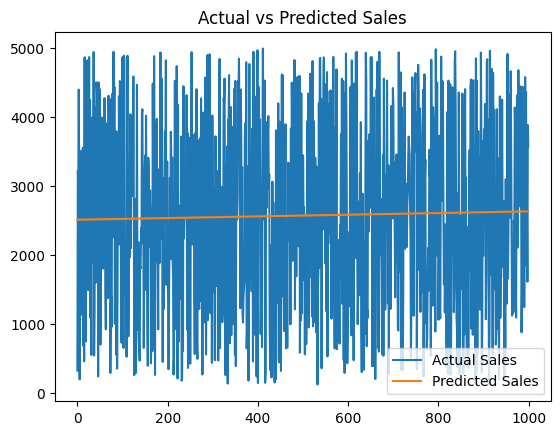

In [18]:
plt.figure()
plt.plot(df_ml["Sales"], label="Actual Sales")
plt.plot(df_ml["Predicted_Sales"], label="Predicted Sales")
plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()

In [19]:
import pandas as pd
import numpy as np

# Assume df already exists
df["Day"] = df["Order_Date"].dt.day
df["Weekday"] = df["Order_Date"].dt.dayofweek
df["Is_Weekend"] = df["Weekday"].isin([5, 6]).astype(int)

# Rolling features (VERY important for forecasting)
df["Rolling_7_Day_Sales"] = (
    df.groupby("Region")["Sales"]
    .transform(lambda x: x.rolling(7, min_periods=1).mean())
)

df.head()

,Order_ID,Order_Date,Region,Category,Sales,Quantity,Year,Month,Day,Weekday,Is_Weekend,Rolling_7_Day_Sales
0,1,2022-01-01,East,Technology,327,8,2022,1,1,5,1,327.000000
1,2,2022-01-02,East,Furniture,3221,3,2022,1,2,6,1,1774.000000
2,3,2022-01-03,South,Technology,2985,2,2022,1,3,0,0,2985.000000
3,4,2022-01-04,South,Technology,4395,3,2022,1,4,1,0,3690.000000
4,5,2022-01-05,South,Technology,3164,6,2022,1,5,2,0,3514.666667


In [20]:
from sklearn.preprocessing import LabelEncoder

le_region = LabelEncoder()
le_category = LabelEncoder()

df["Region_Encoded"] = le_region.fit_transform(df["Region"])
df["Category_Encoded"] = le_category.fit_transform(df["Category"])

df[["Region", "Region_Encoded", "Category", "Category_Encoded"]].head()

,Region,Region_Encoded,Category,Category_Encoded
0,East,0,Technology,2
1,East,0,Furniture,0
2,South,2,Technology,2
3,South,2,Technology,2
4,South,2,Technology,2


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

features = [
    "Quantity",
    "Region_Encoded",
    "Category_Encoded",
    "Is_Weekend",
    "Rolling_7_Day_Sales"
]

X = df[features]
y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("Linear Regression MAE:", mean_absolute_error(y_test, pred_lr))
print("Linear Regression R2:", r2_score(y_test, pred_lr))

Linear Regression MAE: 1015.6164294359166
Linear Regression R2: 0.22890327662186427


In [22]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

print("Random Forest MAE:", mean_absolute_error(y_test, pred_rf))
print("Random Forest R2:", r2_score(y_test, pred_rf))

Random Forest MAE: 1130.0729
Random Forest R2: 0.08538721546812345


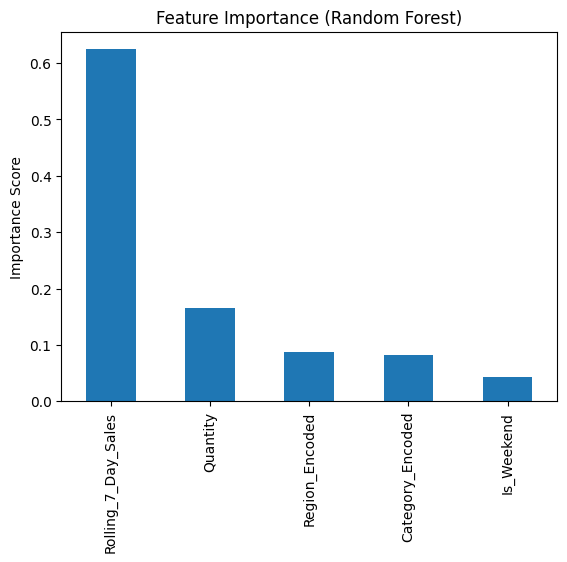

In [23]:
import matplotlib.pyplot as plt
import pandas as pd

importance = pd.Series(
    rf.feature_importances_,
    index=features
).sort_values(ascending=False)

plt.figure()
importance.plot(kind="bar")
plt.title("Feature Importance (Random Forest)")
plt.ylabel("Importance Score")
plt.show()

In [24]:
bi_df = (
    df.groupby(["Order_Date", "Region", "Category"])
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Quantity=("Quantity", "sum"),
        Avg_7Day_Sales=("Rolling_7_Day_Sales", "mean")
    )
    .reset_index()
)

bi_df.head()

,Order_Date,Region,Category,Total_Sales,Total_Quantity,Avg_7Day_Sales
0,2022-01-01,East,Technology,327,8,327.000000
1,2022-01-02,East,Furniture,3221,3,1774.000000
2,2022-01-03,South,Technology,2985,2,2985.000000
3,2022-01-04,South,Technology,4395,3,3690.000000
4,2022-01-05,South,Technology,3164,6,3514.666667


In [26]:
bi_df.to_csv("sales_powerbi_ready.csv", index=False)